# Telco Customer Churn - EDA and Preprocessing

This notebook takes the raw Telco churn dataset, cleans it up, pokes around to see what's
actually driving churn, and ends with a fully numeric dataset ready for modelling.

Rough order of operations: load the data, fix the obvious data issues, look at the target
variable, explore the features against churn, build a couple of new features, encode
everything, scale the numbers, and save the result to `data/telco_customer_churn_processed.csv`.
That file is what the second notebook (`model_training_evaluation.ipynb`) picks up.


## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42


## Loading the data

This is the standard IBM Telco Customer Churn dataset - 7,043 customers, 21 columns.


In [2]:
DATA_PATH = Path("data") / "telco.csv"
if not DATA_PATH.exists():
    DATA_PATH = Path("..") / "data" / "telco.csv"

df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()


(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## A quick look before doing anything

`TotalCharges` shows up as text instead of a number, which is the first hint something's off
with it. There's also a customer ID column we won't need, and a couple of duplicate checks worth
running just to be safe.


In [4]:
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("Unique customer IDs:", df['customerID'].nunique(), "out of", len(df))


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate rows: 0
Unique customer IDs: 7043 out of 7043


In [5]:
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## How balanced is churn?

This matters a lot for what comes next - if one class massively outweighs the other, accuracy
becomes a pretty useless metric and we'll need to think about resampling or class weights
during modelling.


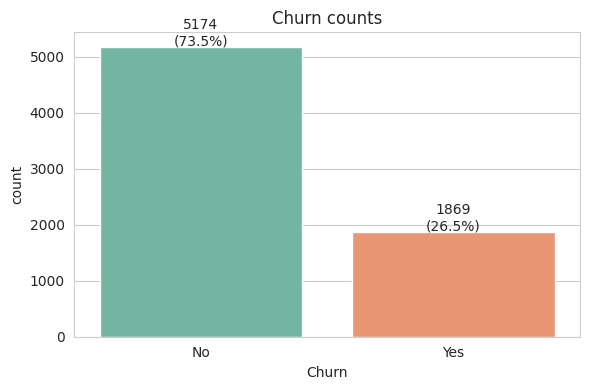

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [6]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df, x='Churn', hue='Churn', palette='Set2', legend=False, ax=ax)
ax.set_title('Churn counts')

for i, v in enumerate(churn_counts):
    ax.text(i, v + 30, f"{v}\n({churn_pct.iloc[i]:.1f}%)", ha='center')

plt.tight_layout()
plt.show()

print(churn_counts)


About 1 in 4 customers churned. Not a wild imbalance, but enough that we should keep an eye on
it - a model that just predicts "no churn" for everyone would still be "right" roughly 73% of
the time and tell us nothing useful.


## Cleaning up

Three things to sort out before we go any further:

- `TotalCharges` is stored as text because 11 rows have it blank - these are all customers
  with `tenure == 0`, i.e. brand new sign-ups who haven't been billed yet. We convert the column
  to numbers and drop those 11 rows (less than 0.2% of the data, and they don't carry useful
  billing info anyway).
- `customerID` is just an ID, drop it.
- `SeniorCitizen` is currently 0/1 but every other yes/no column in this dataset is text
  ("Yes"/"No"). Recoding it to match makes the EDA plots consistent. We'll turn it back into
  0/1 along with the other binary columns later.


In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Rows with missing TotalCharges:", df['TotalCharges'].isnull().sum())
display(df.loc[df['TotalCharges'].isnull(), ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])

df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)
print("Shape now:", df.shape)


Rows with missing TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


Shape now: (7032, 21)


In [8]:
df = df.drop(columns=['customerID'])
df['SeniorCitizen'] = df['SeniorCitizen'].map({1: 'Yes', 0: 'No'})

print("Nulls left:", df.isnull().sum().sum())
print("Duplicates left:", df.duplicated().sum())


Nulls left: 0
Duplicates left: 22


## Tenure, monthly charges, total charges - split by churn

These three numeric columns are usually the first place churn signal shows up.


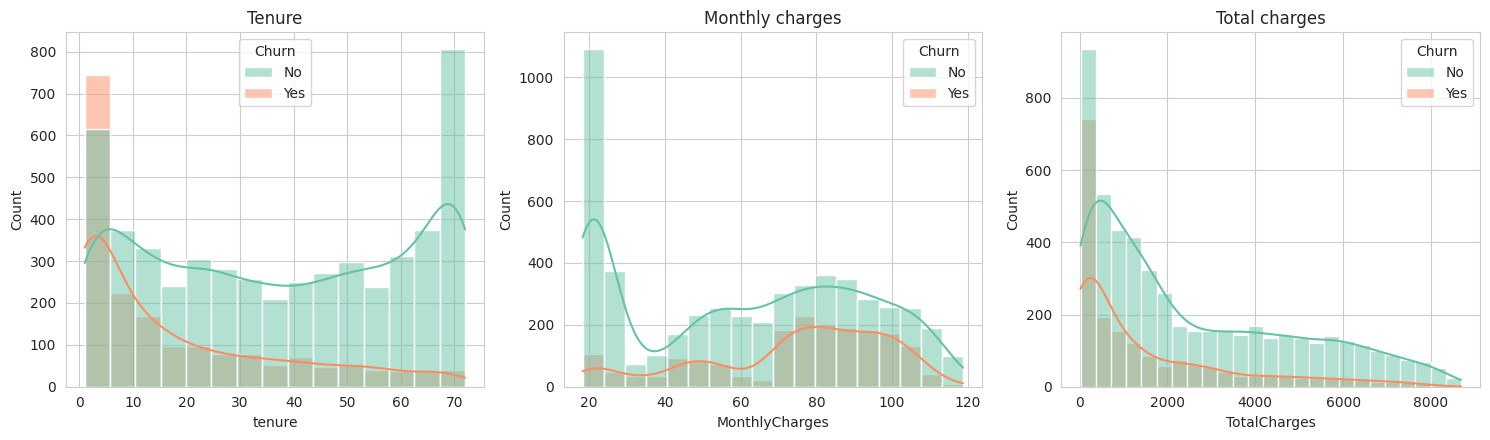

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.histplot(data=df, x='tenure', hue='Churn', kde=True, ax=axes[0], palette='Set2')
axes[0].set_title('Tenure')

sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, ax=axes[1], palette='Set2')
axes[1].set_title('Monthly charges')

sns.histplot(data=df, x='TotalCharges', hue='Churn', kde=True, ax=axes[2], palette='Set2')
axes[2].set_title('Total charges')

plt.tight_layout()
plt.show()


Churned customers cluster heavily at low tenure - lots of people leaving in their first few
months. They also skew toward higher monthly charges. `TotalCharges` tracks tenure closely
(makes sense, it's basically accumulated billing), and we'll see that again in the correlation
heatmap further down.


## Categorical features vs churn

Grouped into three chunks so the plots don't turn into an unreadable wall: services the
customer has signed up for, demographics, and account/billing details.


In [10]:
services = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
demographics = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
account_info = ['Contract', 'PaperlessBilling', 'PaymentMethod']


def plot_vs_churn(data, features, title):
    n_cols = 2
    n_rows = (len(features) + 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, n_rows * 3.2))
    axes = axes.flatten()

    for i, col in enumerate(features):
        sns.countplot(data=data, x=col, hue='Churn', palette='Set2', ax=axes[i])
        axes[i].set_title(col)
        axes[i].tick_params(axis='x', rotation=30)

    for j in range(len(features), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(title, y=1.02, fontsize=15)
    plt.tight_layout()
    plt.show()


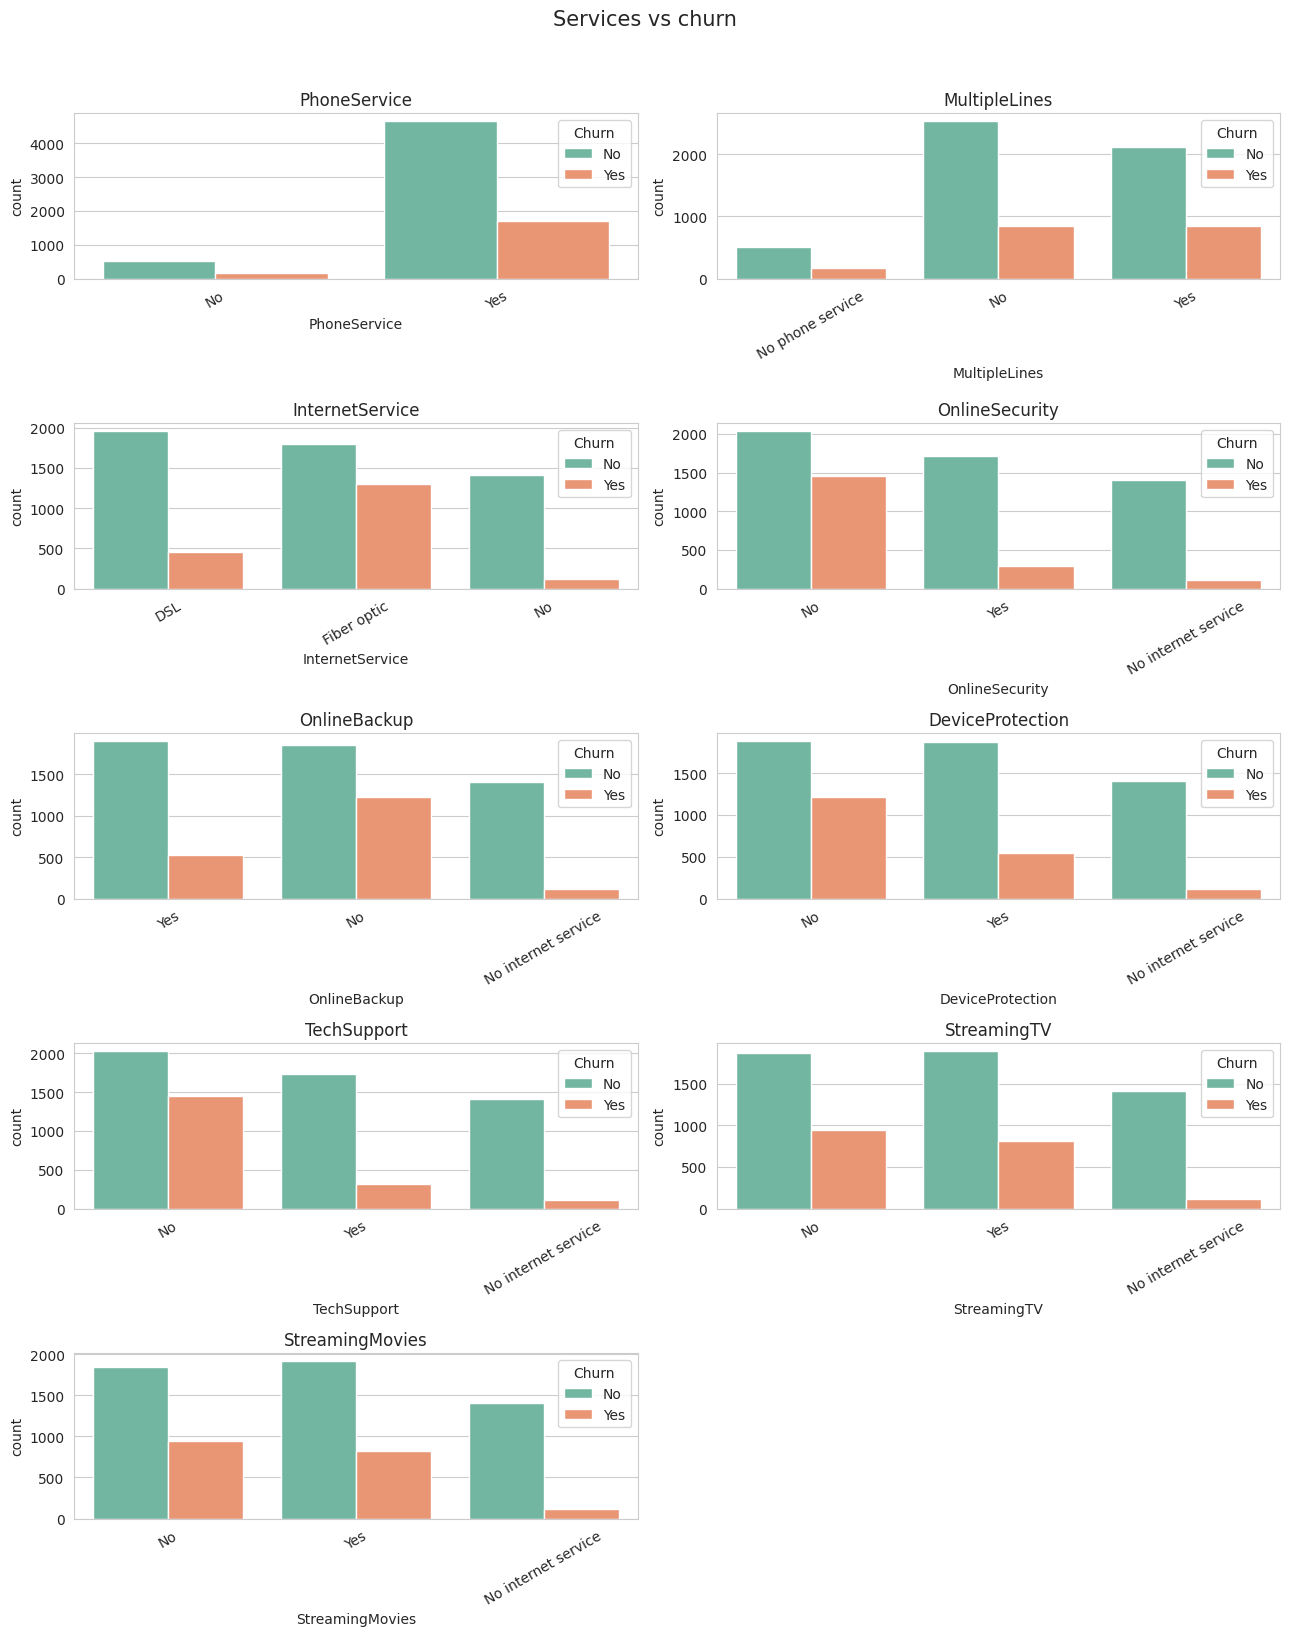

In [11]:
plot_vs_churn(df, services, "Services vs churn")


Customers without `OnlineSecurity` or `TechSupport` churn noticeably more than those who have
them. Fiber optic internet customers also churn more than DSL or no-internet customers - maybe
price, maybe service quality, the data alone won't tell us which.


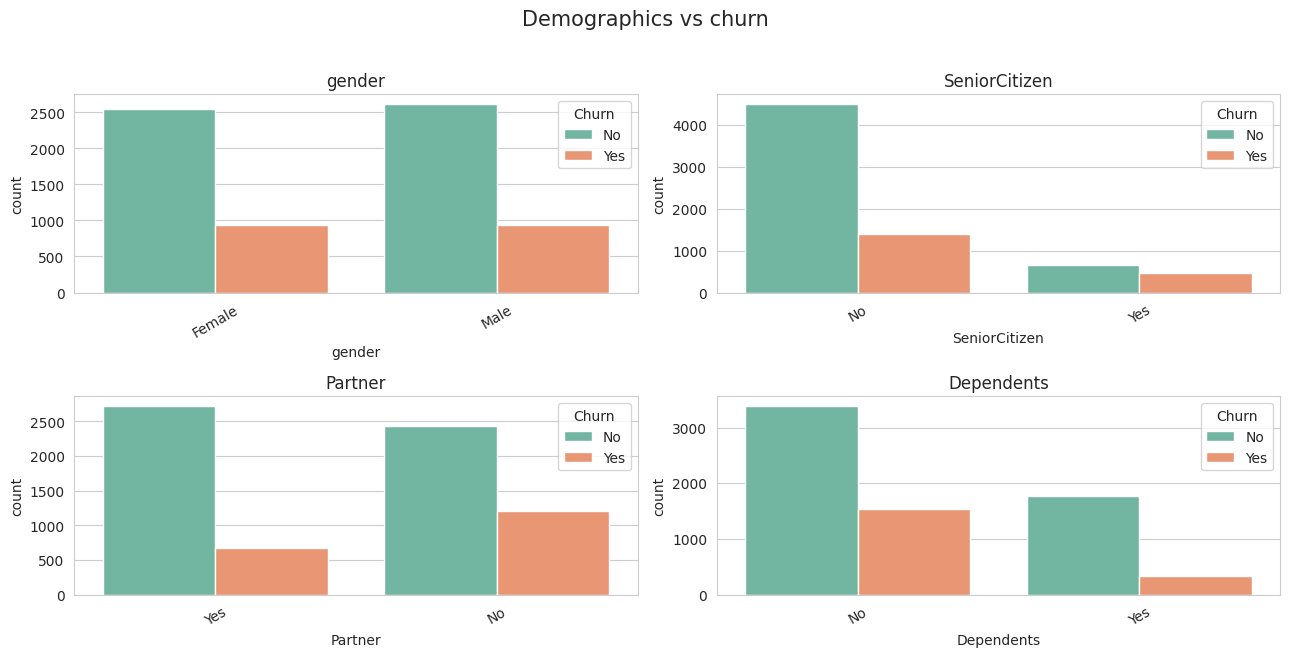

In [12]:
plot_vs_churn(df, demographics, "Demographics vs churn")


Gender barely makes a difference here. Senior citizens, and customers without a partner or
dependents, churn a bit more - though none of these are huge effects on their own.


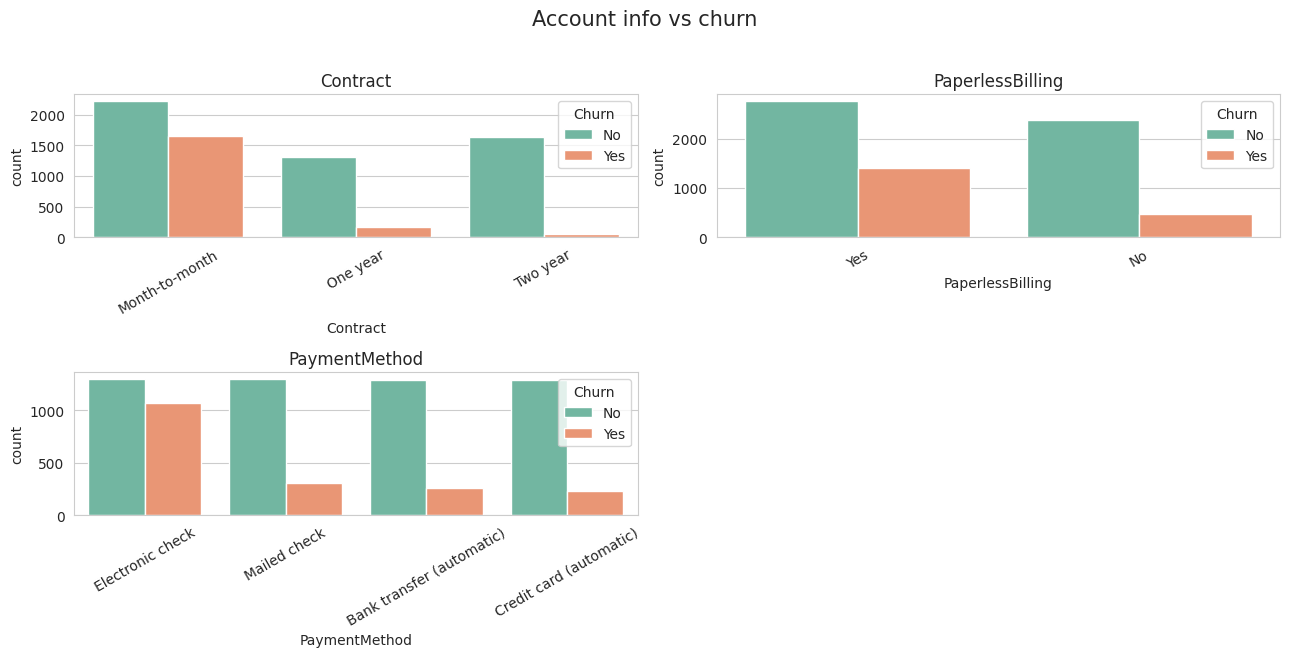

In [13]:
plot_vs_churn(df, account_info, "Account info vs churn")


This is probably the strongest pattern in the whole dataset - month-to-month customers churn
way more than people on one or two year contracts. Paying by electronic check and having
paperless billing also line up with higher churn.


## Correlations

To check correlations against the numeric columns we need `Churn` as 0/1 instead of Yes/No.


In [14]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(numeric_cols)


['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']


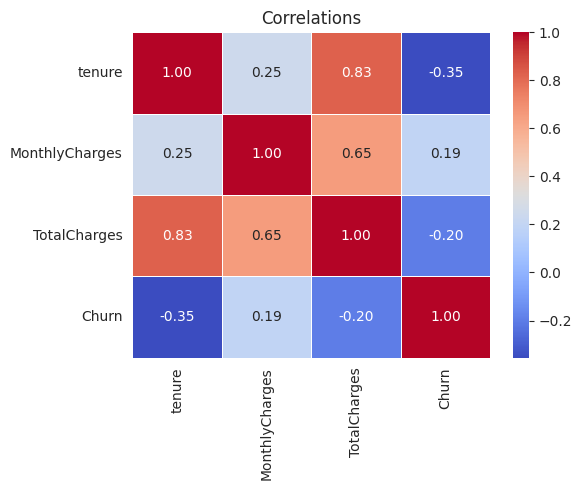

In [15]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlations')
plt.tight_layout()
plt.show()


`tenure` and `TotalCharges` are correlated at 0.83, which tracks - customers who've been around
longer have racked up more in total charges. `tenure` has the strongest (negative) link to
churn out of the numeric columns, while `MonthlyCharges` leans positive. The tenure/TotalCharges
overlap isn't a big deal for tree-based models, and we'll add a feature below that combines the
two in a more useful way.


## Checking for outliers

Quick IQR check on the numeric columns, just to look - not to remove anything. Telco billing
data legitimately spans a wide range (long-term customers on premium plans rack up big totals),
so high values here aren't errors.


/tmp/ipykernel_534/3653054184.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_processed, x='Churn', y=col, ax=ax, palette='Set2')
/tmp/ipykernel_534/3653054184.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_processed, x='Churn', y=col, ax=ax, palette='Set2')
/tmp/ipykernel_534/3653054184.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_processed, x='Churn', y=col, ax=ax, palette='Set2')


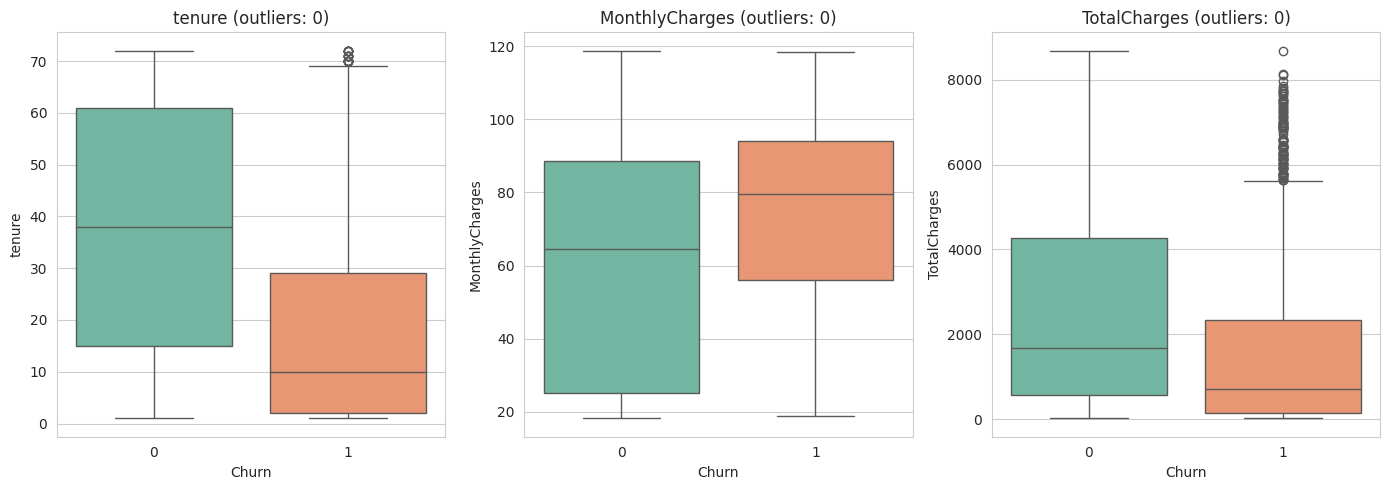

In [16]:
df_processed = df.copy()
numeric_for_outliers = [c for c in numeric_cols if c != 'Churn']

fig, axes = plt.subplots(1, len(numeric_for_outliers), figsize=(14, 5))

for ax, col in zip(axes, numeric_for_outliers):
    Q1, Q3 = df_processed[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out = ((df_processed[col] < lower) | (df_processed[col] > upper)).sum()

    sns.boxplot(data=df_processed, x='Churn', y=col, ax=ax, palette='Set2')
    ax.set_title(f'{col} (outliers: {n_out})')

plt.tight_layout()
plt.show()


`tenure` has zero outliers by this measure, since it's capped at 72 by design. `MonthlyCharges`
and `TotalCharges` have a handful of high values on the upper end - these are just genuinely
high-spend, long-tenure customers, nothing to clean up.


## Two new features

- `tenure_bins` - groups tenure into 0-12, 13-24, 25-48, 49-72 month buckets. A single number
  for tenure can hide the fact that "new customer risk" doesn't decay linearly.
- `avg_monthly_spend` - `TotalCharges / tenure`, i.e. roughly how much this customer spends per
  month on average over their whole time with the company. We already dropped the tenure=0 rows
  earlier, so dividing by tenure is safe here, but the `np.where` guard is left in just in case.


In [17]:
df_processed['tenure_bins'] = pd.cut(
    df_processed['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0-12 months', '13-24 months', '25-48 months', '49-72 months'],
    include_lowest=True,
)

df_processed['avg_monthly_spend'] = np.where(
    df_processed['tenure'] > 0,
    df_processed['TotalCharges'] / df_processed['tenure'],
    df_processed['MonthlyCharges'],
)

print("Missing values:", df_processed['avg_monthly_spend'].isnull().sum())
df_processed[['tenure', 'tenure_bins', 'TotalCharges', 'avg_monthly_spend']].head()


Missing values: 0


,tenure,tenure_bins,TotalCharges,avg_monthly_spend
0,1,0-12 months,29.85,29.850000
1,34,25-48 months,1889.50,55.573529
2,2,0-12 months,108.15,54.075000
3,45,25-48 months,1840.75,40.905556
4,2,0-12 months,151.65,75.825000


## Do these new features actually mean anything?

Worth checking the churn rate within each bucket before trusting these features.


In [18]:
def churn_rate_table(data, feature_column):
    table = pd.crosstab(data[feature_column], data['Churn'], margins=True, margins_name='Total')
    table['Churn Rate'] = (table[1] / table['Total']).round(3)
    return table


display(churn_rate_table(df_processed, 'tenure_bins'))

df_processed['avg_monthly_spend_bins'] = pd.qcut(df_processed['avg_monthly_spend'], q=4, duplicates='drop')
display(churn_rate_table(df_processed, 'avg_monthly_spend_bins'))

df_processed = df_processed.drop(columns=['avg_monthly_spend_bins'])


Churn,0,1,Total,Churn Rate
tenure_bins,,,,
0-12 months,1138,1037,2175,0.477
13-24 months,730,294,1024,0.287
25-48 months,1269,325,1594,0.204
49-72 months,2026,213,2239,0.095
Total,5163,1869,7032,0.266


Churn,0,1,Total,Churn Rate
avg_monthly_spend_bins,,,,
"(13.774000000000001, 36.18]",1561,197,1758,0.112
"(36.18, 70.373]",1312,446,1758,0.254
"(70.373, 90.18]",1120,638,1758,0.363
"(90.18, 121.4]",1170,588,1758,0.334
Total,5163,1869,7032,0.266


Churn drops from roughly 47% in the 0-12 month bucket down to about 9% in the 49-72 month
bucket - that's a real signal, not noise. Churn rate also climbs as `avg_monthly_spend` goes up,
which matches what we saw with `MonthlyCharges` earlier.


## Encoding categorical columns

Three approaches depending on what the column looks like:

- Plain yes/no columns (`Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`,
  `SeniorCitizen`) become 1/0.
- `gender` becomes 1 for Male, 0 for Female.
- Everything else with multiple categories (`InternetService`, `Contract`, `PaymentMethod`,
  `tenure_bins`, etc.) gets one-hot encoded, dropping the first category each time to avoid
  redundant columns.

One small detail: depending on the pandas version, text columns can come in as either `object`
or the newer string dtype, so the check below covers both.


In [19]:
def is_textlike(series):
    return pd.api.types.is_object_dtype(series) or pd.api.types.is_string_dtype(series)


binary_cols = [
    c for c in df_processed.columns
    if is_textlike(df_processed[c]) and set(df_processed[c].dropna().unique()).issubset({'Yes', 'No'})
]
print("Binary columns:", binary_cols)

for c in binary_cols:
    df_processed[c] = df_processed[c].map({'Yes': 1, 'No': 0})

df_processed['gender'] = df_processed['gender'].map({'Female': 0, 'Male': 1})

remaining_cat_cols = [
    c for c in df_processed.columns
    if (is_textlike(df_processed[c]) or isinstance(df_processed[c].dtype, pd.CategoricalDtype))
    and c not in binary_cols + ['gender']
]
print("One-hot columns:", remaining_cat_cols)

df_processed = pd.get_dummies(df_processed, columns=remaining_cat_cols, drop_first=True)
print("Shape now:", df_processed.shape)
df_processed.head()


Binary columns: ['SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
One-hot columns: ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod', 'tenure_bins']
Shape now: (7032, 35)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_bins_13-24 months,tenure_bins_25-48 months,tenure_bins_49-72 months
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,True,False,False,False,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,True,False,False,False,True,False,True,False
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,True,False,False,False
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,False,False,True,False,False,False,False,False,True,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,True,False,False,False,False


## Scaling

`StandardScaler` on the continuous columns - `tenure`, `MonthlyCharges`, `TotalCharges`,
`avg_monthly_spend`. The binary and one-hot columns are already 0/1, so they're left alone.

One caveat worth flagging: this scaler is fit on the whole dataset for simplicity. In the
modelling notebook we fit a fresh scaler on the training split only, to avoid any leakage from
the test set into the scaling statistics. If you're building this into a production pipeline,
it's cleaner to skip scaling here entirely and do it inside a `sklearn.Pipeline` using
train-only stats.


In [20]:
from sklearn.preprocessing import StandardScaler

continuous_features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'avg_monthly_spend']

scaler = StandardScaler()
df_processed[continuous_features] = scaler.fit_transform(df_processed[continuous_features])

df_processed[continuous_features].describe().round(3)


,tenure,MonthlyCharges,TotalCharges,avg_monthly_spend
count,7032.000,7032.000,7032.000,7032.000
mean,-0.000,0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000
min,-1.280,-1.547,-0.999,-1.690
25%,-0.954,-0.971,-0.830,-0.948
50%,-0.139,0.185,-0.391,0.185
75%,0.920,0.833,0.667,0.841
max,1.613,1.793,2.824,1.875


## Final checks and saving

Make sure there's nothing left over before writing the file out.


In [21]:
print("Rows:", df_processed.shape[0])
print("Columns:", df_processed.shape[1])
print("Missing values:", df_processed.isnull().sum().sum())
print("Duplicate rows:", df_processed.duplicated().sum())

non_numeric = [c for c in df_processed.columns if not pd.api.types.is_numeric_dtype(df_processed[c])]
print("Non-numeric columns:", non_numeric or "none")


Rows: 7032
Columns: 35
Missing values: 0
Duplicate rows: 22
Non-numeric columns: none


In [22]:
output_dir = Path("data")
output_dir.mkdir(parents=True, exist_ok=True)
output_path = output_dir / "telco_customer_churn_processed.csv"

df_processed.to_csv(output_path, index=False)

print(f"Saved to {output_path.resolve()}")
print(f"Shape: {df_processed.shape}")
print(df_processed['Churn'].value_counts())


Saved to /home/claude/data/telco_customer_churn_processed.csv
Shape: (7032, 35)
Churn
0    5163
1    1869
Name: count, dtype: int64


## Where this leaves us

- Dropped 11 rows with bad `TotalCharges` values and removed `customerID`.
- Churn sits at roughly 73/27, so the modelling notebook handles that with SMOTE and class
  weights.
- The clearest churn signals so far: tenure, contract type, having `OnlineSecurity` /
  `TechSupport` or not, and monthly charges.
- Added `tenure_bins` and `avg_monthly_spend`, both of which show a clean gradient in churn rate.
- Everything is now numeric and scaled, saved to `data/telco_customer_churn_processed.csv` for
  the next notebook.
